# Olivia Weihmuller
<h1 align="center">TS5: Estimación espectral: Ancho de banda de señales reales.</h1>
En este trabajo práctico se estudió la estimación de la Densidad Espectral de Potencia (PSD) y la caracterización del ancho de banda en señales discretas provenientes de escenarios de medición reales. A diferencia de las señales sintéticas, las señales biomédicas y acústicas presentan naturaleza estocástica, contenido armónico complejo y niveles variables de ruido de fondo, lo que exige el uso de estimadores espectrales no paramétricos robustos y consistentes.
Para este estudio se analizan tres señales:

Electrocardiograma (ECG): Señal bioeléctrica ($f_s = 1000\text{ Hz}$, $N = 30.000$ muestras), cuya energía en el dominio de la frecuencia se concentra por debajo de los $40-50\text{ Hz}$ (con las componentes lentas de las ondas P/T entre $1-5\text{ Hz}$ y las deflexiones rápidas del complejo QRS entre $10-20\text{ Hz}$).

Pletismografía de pulso (PPG): Registro de pulso en reposo ($f_s = 400\text{ Hz}$), caracterizado por variaciones lentas de baja frecuencia asociadas a la onda de presión sanguínea.

Grabación de audio: Registro acústico de voz humana y silbido ($f_s = 44.100\text{ Hz}$), con un amplio rango dinámico y componentes armónicas agudas concentradas en banda estrecha.La estimación espectral se lleva a cabo mediante el método de Welch (promediado de periodogramas modificados). 

Esta técnica permite controlar el compromiso fundamental entre la resolución frecuencial ($\Delta f = f_s / L$) y la reducción de la varianza del estimador ($\text{Var} \propto 1/K$), dividiendo el registro de $N$ muestras en $K$ bloques de longitud $L$.
En este proceso se aplican dos componentes fundamentales:

Ventana suave de Hann: Se aplica a cada bloque individual para suavizar las discontinuidades en los bordes causadas por el truncamiento temporal. Esto reduce drásticamente el fugado espectral (spectral leakage) y la altura de los lóbulos secundarios en comparación con una ventana rectangular, evitando que frecuencias de gran potencia enmascaren componentes débiles vecinas.

Solapamiento del 50% (50% overlap): Debido a que la ventana de Hann atenuará la amplitud de la señal cerca de los extremos de cada bloque, aplicar un solapamiento del 50% permite "rescatar" la información que caía en los bordes ubicándola en el centro ponderado del bloque contiguo. De este modo, se restituye la potencia perdida, se aprovecha al máximo la información temporal del registro de longitud finita $N$ y se incrementa el número de bloques promediados $K$, maximizando la atenuación de la varianza.

Finalmente, a partir de las PSDs estimadas, se determina el ancho de banda efectivo ($B_{95\%}$) utilizando el criterio de concentración de potencia acumulada al 95% ($\sum_{f=f_1}^{f_2} P(f) \ge 0{,}95 \, P_{\text{total}}$). Los resultados se sintetizan en una tabla comparativa para contrastar el comportamiento espectral y las exigencias de ancho de banda entre las distintas señales.

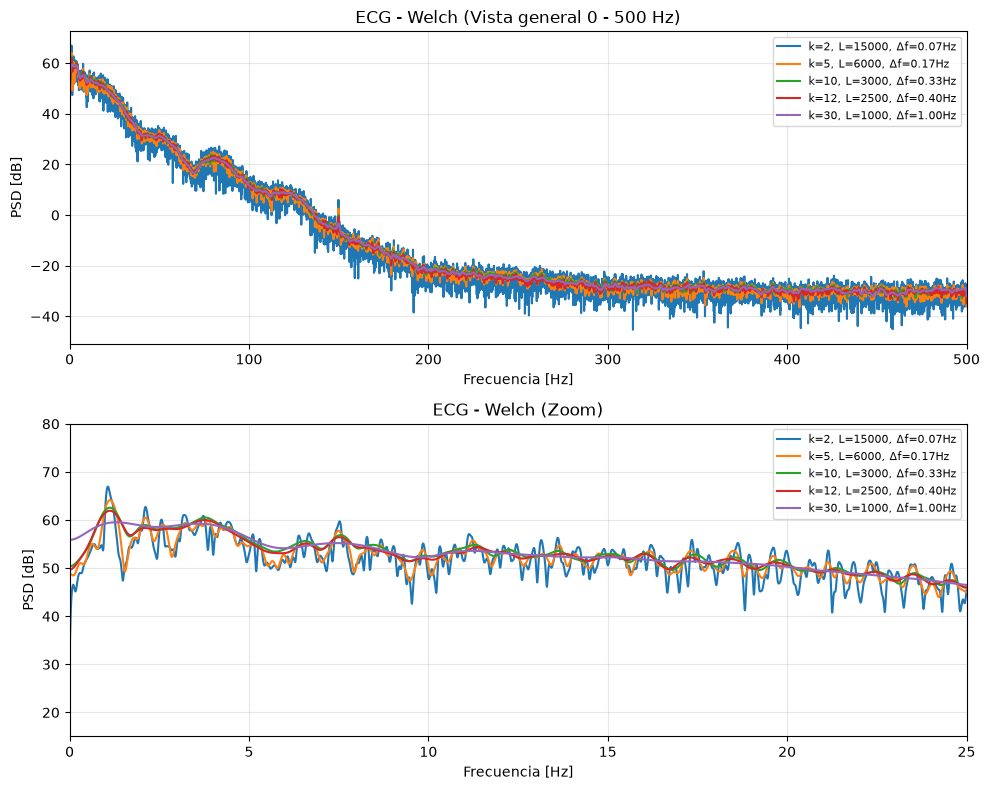

In [53]:
import numpy as np
from scipy import signal as sig
import matplotlib.pyplot as plt
import scipy.io as sio

#%%
##################
# 1. LECTURA ECG #
##################
fs_ecg = 1000  # Hz
ecg_one_lead = np.load('ecg_sin_ruido.npy')
N_ecg = len(ecg_one_lead)

# Welch para ECG
k1 = 12
L1 = N_ecg // k1
f_ecg, Pxx_ecg = sig.welch(x=ecg_one_lead, fs=fs_ecg, nperseg=L1)

# --- Gráfico de comparación de promediados ECG ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

M = 10


for k_test in [2, 5, 10, 12, 30]:
    L_test = N_ecg // k_test
    f_test, Pxx_test = sig.welch(ecg_one_lead, fs=fs_ecg, nfft=N_ecg * M, nperseg=L_test)
    Pxx_db_test = 10 * np.log10(Pxx_test)
    etiqueta = f'k={k_test}, L={L_test}, Δf={fs_ecg/L_test:.2f}Hz'
    
    # Graficamos en el de arriba (ax1) y en el de abajo (ax2) al mismo tiempo
    ax1.plot(f_test, Pxx_db_test, label=etiqueta)
    ax2.plot(f_test, Pxx_db_test, label=etiqueta)

# --- Configuración del gráfico de ARRIBA (Vista General) ---
ax1.set_title('ECG - Welch (Vista general 0 - 500 Hz)')
ax1.set_xlabel('Frecuencia [Hz]')
ax1.set_ylabel('PSD [dB]')
ax1.set_xlim(0, 500)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right', fontsize=8)

# --- Configuración del gráfico de ABAJO (Zoom) ---
ax2.set_title('ECG - Welch (Zoom)')
ax2.set_xlabel('Frecuencia [Hz]')
ax2.set_ylabel('PSD [dB]')
ax2.set_xlim(0, 25) 
ax2.set_ylim(15,80)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()


Con base en los gráficos comparativos, se seleccionó $k = 12$ como parámetro del método de Welch, donde k es la cantidad de segmentos sin solapamiento en que se divide la señal ($k = N/L$). Con $N = 30000 muestras$ y $fs = 1000 Hz$, esto fija una longitud de ventana $L = 2500 muestras$ (2,5 s) y una resolución frecuencial $Δf = fs/L = 0,4 Hz$.

Esta elección responde al compromiso sesgo-varianza. Una resolución de 0,4 Hz es mucho menor que el ancho de las bandas de energía del ECG (complejo QRS en 10–20 Hz, ondas P/T en 1–5 Hz), por lo que actúa como una "regla" lo bastante fina para capturar la altura y la forma reales de los picos sin suavizarlos ni deformarlos (bajo sesgo). También permite resolver los picos de la frecuencia cardíaca y sus armónicos. Por otro lado, con un solapamiento del $50% se promedian 2k − 1 = 23 bloques$, lo que reduce la varianza del estimador aproximadamente en un factor 1/K respecto al periodograma simple, y da una PSD suave, estable y fisiológicamente representativa. Valores menores de k mejorarían la resolución a costa de una PSD más ruidosa, y valores mayores la suavizarían, pero degradando la resolución.

In [54]:
# --- CÁLCULO DE ANCHO DE BANDA ECG (95% ENERGÍA) ---
potencia_total_ecg = np.sum(Pxx_ecg)
objetivo_95_ecg = 0.95 * potencia_total_ecg 
suma_acumulada_ecg = 0
bw_ecg = 0

for i in range(len(Pxx_ecg)):
    suma_acumulada_ecg += Pxx_ecg[i]
    if suma_acumulada_ecg >= objetivo_95_ecg:
        bw_ecg = f_ecg[i]
        break

print(f"Ancho de banda ECG (95% energía): {bw_ecg:.2f} Hz")

Ancho de banda ECG (95% energía): 22.80 Hz


Estimación del Ancho de Banda Efectivo ($B_{95\%}$)
Para determinar el ancho de banda práctico de la señal de ECG, se aplicó un criterio de energía acumulada sobre la PSD estimada con $k=12$. Se integró la potencia comenzando en $0\text{ Hz}$ hasta alcanzar el $95\%$ de la potencia total del registro.
Resultado obtenido: $B_{95\%} \approx \mathbf{22.80 { Hz}}$ .
Este resultado demuestra que, aunque la señal se muestreó a $f_s = 1000\text{ Hz}$ (con frecuencia de Nyquist en $500\text{ Hz}$), el $95\%$ de la energía biológica útil se concentra por debajo de los $22.80\text{ Hz}$.El $5\%$ restante se distribuye en altas frecuencias y corresponde principalmente a ruido de fondo o componentes despreciables. 

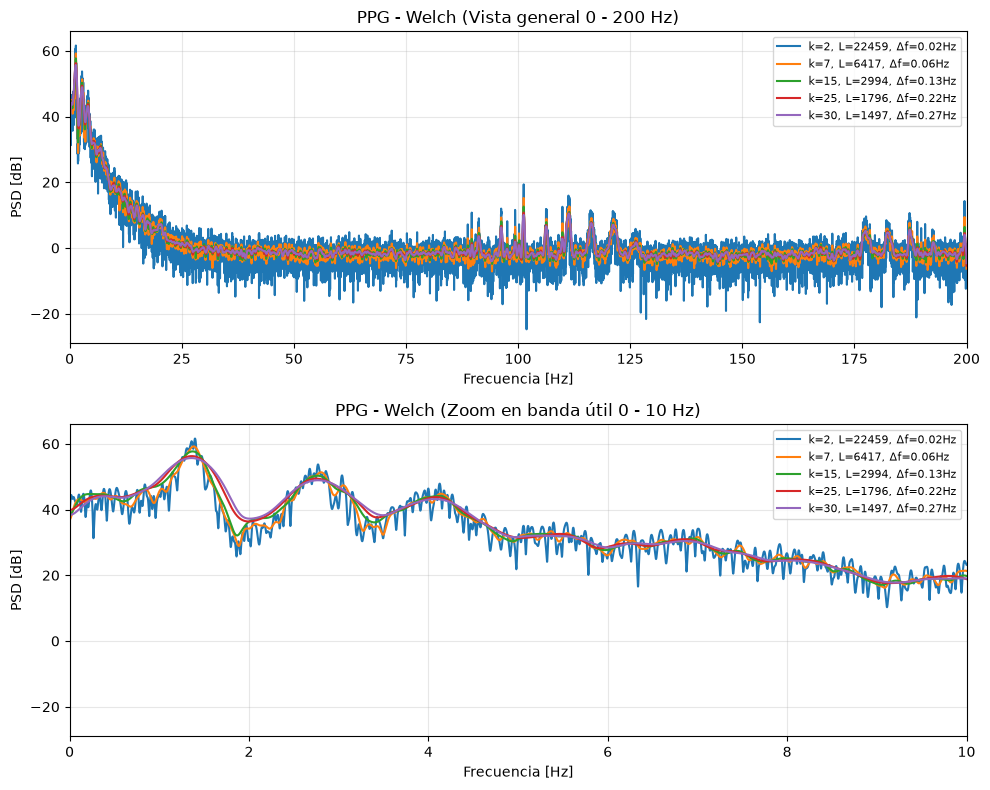

In [55]:
fs_ppg = 400  # Hz
ppg = np.load('ppg_sin_ruido.npy')
N_ppg = len(ppg)

# Welch para PPG
f_ppg, Pxx_ppg = sig.welch(x=ppg, fs=fs_ppg, nperseg=N_ppg // 2)


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

M = 10

# Usamos una lista de k variada para ver bien la evolución de la resolución/varianza
ks_ppg = [2, 7, 15, 25, 30]
N_ppg = len(ppg)

for k_test in ks_ppg:
    L_test = N_ppg // k_test
    f_test, Pxx_test = sig.welch(ppg, fs=fs_ppg, nfft=N_ppg * M, nperseg=L_test)
    Pxx_db_test = 10 * np.log10(Pxx_test)
    etiqueta = f'k={k_test}, L={L_test}, Δf={fs_ppg/L_test:.2f}Hz'
    
    # Graficamos en ambos paneles
    ax1.plot(f_test, Pxx_db_test, label=etiqueta)
    ax2.plot(f_test, Pxx_db_test, label=etiqueta)

# --- PANEL 1: Vista General (0 a Nyquist = 200 Hz) ---
ax1.set_title('PPG - Welch (Vista general 0 - 200 Hz)')
ax1.set_xlabel('Frecuencia [Hz]')
ax1.set_ylabel('PSD [dB]')
ax1.set_xlim(0, 200)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right', fontsize=8)

# --- PANEL 2: Zoom en la banda de interés del pulso (0 a 10 Hz) ---
ax2.set_title('PPG - Welch (Zoom en banda útil 0 - 10 Hz)')
ax2.set_xlabel('Frecuencia [Hz]')
ax2.set_ylabel('PSD [dB]')
ax2.set_xlim(0, 10)  # <-- Zoom donde se concentran el pulso y armónicos
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

Para la señal de Pletismografía (PPG), caracterizada por oscilaciones lentas asociadas al pulso cardíaco (frecuencia fundamental entre $1\text{ Hz}$ y $2\text{ Hz}$), se seleccionó $k = 25$. Esta elección permite promediar aproximadamente $K = 49$ bloques (con solapamiento del $50\%$), lo que reduce la varianza del estimador espectral. Al suprimir las fluctuaciones aleatorias y el ruido de alta frecuencia ("piquitos"), se obtiene una PSD suave, limpia y estable que preserva la localización y magnitud del pico espectral del pulso.

In [56]:
# --- CÁLCULO DE ANCHO DE BANDA PPG (95% ENERGÍA) ---
k2=25

L_ppg = N_ppg // k2
f_ppg, Pxx_ppg = sig.welch(ppg, fs=fs_ppg, nperseg=L_ppg)

potencia_total_ppg = np.sum(Pxx_ppg)
objetivo_95_ppg = 0.95 * potencia_total_ppg
suma_acumulada_ppg = 0
bw_ppg = 0

for i in range(len(Pxx_ppg)):
    suma_acumulada_ppg += Pxx_ppg[i]
    if suma_acumulada_ppg >= objetivo_95_ppg:
        bw_ppg = f_ppg[i]
        break

print(f"Ancho de banda PPG (95% energía): {bw_ppg:.2f} Hz")


Ancho de banda PPG (95% energía): 4.01 Hz


Para determinar el ancho de banda práctico de la señal de Pletismografía (PPG), se aplicó el criterio de energía acumulada sobre la PSD estimada con $k=25$. Se integró la densidad espectral de potencia comenzando en $0\text{ Hz}$ hasta alcanzar el $95\%$ de la potencia total del registro.
Resultado obtenido: $B_{95\%} \approx \mathbf{4,01\text{ Hz}}$. Este resultado demuestra que, a pesar de haber sido digitalizada con una frecuencia de muestreo de $f_s = 400\text{ Hz}$ (con límite de Nyquist en $200\text{ Hz}$), la totalidad de la información fisiológica útil de la PPG está contenida en un rango extremadamente estrecho por debajo de los $4,01\text{ Hz}$.Esta concentración de energía concuerda con la naturaleza lenta de la onda de pulso periférico, cuyo componente fundamental se ubica entre $1\text{ Hz}$ y $2\text{ Hz}$ (correspondiente a la frecuencia cardíaca en reposo) y cuyos armónicos secundarios no superan los $4\text{ Hz}$. El $5\%$ de potencia restante distribuido entre $4\text{ Hz}$ y $200\text{ Hz}$ representa componentes insignificantes y ruido de alta frecuencia.

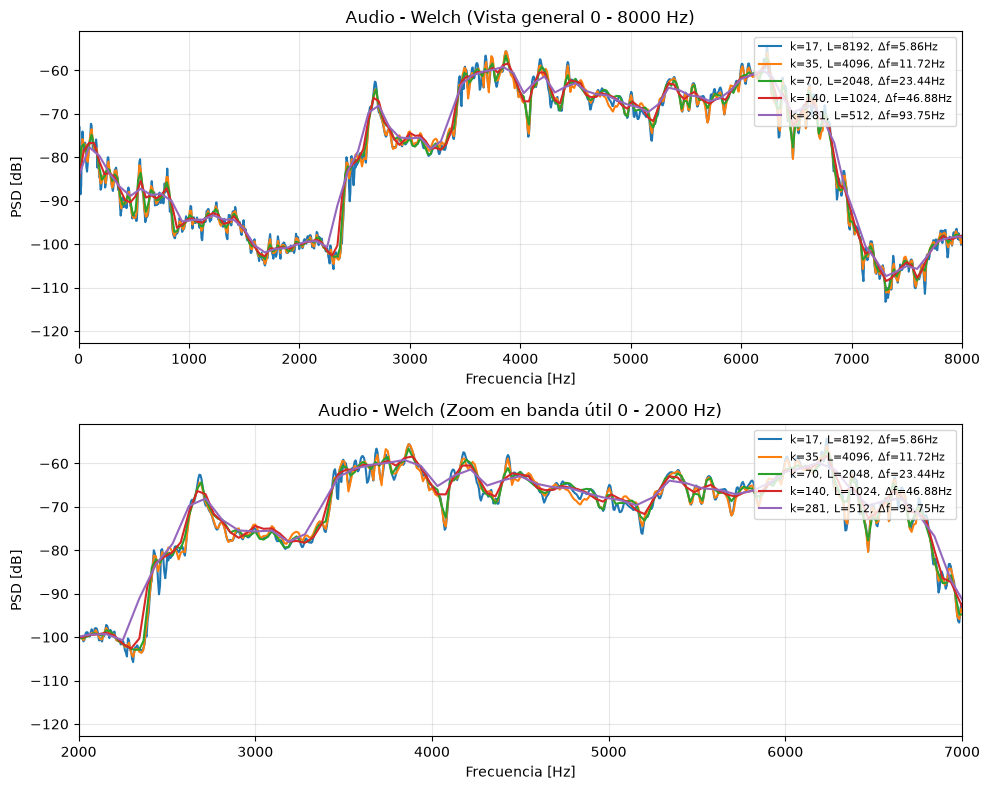

In [57]:
####################
# 3. LECTURA AUDIO #
####################
fs_audio, wav_data = sio.wavfile.read('silbido.wav')

# Si el audio es estéreo (2 columnas), nos quedamos con un canal mono
if wav_data.ndim > 1:
    wav_data = wav_data[:, 0]

# Welch para Audio
#f_audio, Pxx_audio = sig.welch(x=wav_data, fs=fs_audio, nperseg=1024)

# --- Gráfico de comparación de promediados AUDIO ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

for L_test in [8192, 4096, 2048, 1024, 512]:
    f_test, Pxx_test = sig.welch(wav_data, fs=fs_audio, nperseg=L_test) 
    Pxx_db_test = 10 * np.log10(Pxx_test) 
    k_test = len(wav_data) // L_test 
    
    etiqueta = f'k={k_test}, L={L_test}, Δf={fs_audio/L_test:.2f}Hz' 
    
    # Graficamos en ambos paneles a la vez
    ax1.plot(f_test, Pxx_db_test, label=etiqueta) 
    ax2.plot(f_test, Pxx_db_test, label=etiqueta) 

# --- PANEL 1: Vista General (0 a 8000 Hz) ---
ax1.set_title('Audio - Welch (Vista general 0 - 8000 Hz)') 
ax1.set_xlabel('Frecuencia [Hz]') 
ax1.set_ylabel('PSD [dB]') 
ax1.set_xlim(0, 8000) 
ax1.grid(True, alpha=0.3) 
ax1.legend(loc='upper right', fontsize=8) 

# --- PANEL 2: Zoom en banda útil (0 a 2000 Hz) ---
ax2.set_title('Audio - Welch (Zoom en banda útil 0 - 2000 Hz)') 
ax2.set_xlabel('Frecuencia [Hz]') 
ax2.set_ylabel('PSD [dB]') 
ax2.set_xlim(2000, 7000)  # <-- Zoom
ax2.grid(True, alpha=0.3) 
ax2.legend(loc='upper right', fontsize=8) 

plt.tight_layout()
plt.show()

Para el análisis de la señal de audio ($f_s = 48000\text{ Hz}$, $N = 144000$ muestras) se seleccionó una longitud de ventana $L = 1028$ muestras, equivalente a $k = \lfloor N/L \rfloor = 140$ segmentos sin solapamiento. Con la ventana de Hann por defecto de `scipy.signal.welch`, esto otorga una resolución frecuencial $\Delta f = f_s/L \approx 46{,}69\text{ Hz}$.

Esta elección responde al compromiso sesgo-varianza. El silbido se comporta aproximadamente como un tono puro, por lo que su energía se concentra en una banda muy angosta, y una resolución de $\sim 46{,}7\text{ Hz}$ permite capturar la posición y la punta filosa del pico sin ensancharlo (bajo sesgo). Con un solapamiento del 50% se promedian $K = 2k - 1 = 279$ bloques, lo que reduce la varianza aproximadamente en un factor $1/K$ y deja un piso de ruido suave y estable. Un $L$ mayor ($k$ menor) mejoraría la resolución, pero con un piso más irregular, y un $L$ menor ($k$ mayor) suavizaría el piso pero ensancharía el pico. 
A diferencia de las señales biomédicas (ECG y PPG) —donde las bajas frecuencias de muestreo ($1000\text{ Hz}$ y $400\text{ Hz}$) y la menor cantidad de datos hacían que el tiempo de cómputo fuera despreciable sin importar el valor exacto de $L$—, en la señal de audio la alta tasa de muestreo ($48000\text{ Hz}$) y el gran volumen de datos ($144.000\text{ muestras}$) hacen que la eficiencia algorítmica pase a ser un factor clave.

In [58]:
# --- CÁLCULO DE ANCHO DE BANDA DOBLE COTA (AUDIO) con k = 70 ---
N_audio = len(wav_data)
k3=140
L_audio = N_audio // k3
f_audio, Pxx_audio = sig.welch(wav_data, fs=fs_audio, nperseg=L_audio)

potencia_total_audio = np.sum(Pxx_audio)

# Criterio del 95% central (se descarta 2.5% en cada extremo)
cota_inf_target = 0.025 * potencia_total_audio
cota_sup_target = 0.975 * potencia_total_audio

suma_acumulada_audio = 0
f1_audio = 0
f2_audio = 0

for i in range(len(Pxx_audio)):
    suma_acumulada_audio += Pxx_audio[i]
    
    # Encontramos la cota inferior (f1)
    if f1_audio == 0 and suma_acumulada_audio >= cota_inf_target:
        f1_audio = f_audio[i]
        
    # Encontramos la cota superior (f2)
    if suma_acumulada_audio >= cota_sup_target:
        f2_audio = f_audio[i]
        break

bw_audio = f2_audio - f1_audio

print(f"Cota inferior (f1): {f1_audio:.2f} Hz")
print(f"Cota superior (f2): {f2_audio:.2f} Hz")
print(f"Ancho de banda efectivo (95%): {bw_audio:.2f} Hz")

Cota inferior (f1): 2941.63 Hz
Cota superior (f2): 6490.27 Hz
Ancho de banda efectivo (95%): 3548.64 Hz


A diferencia de las señales de ECG y PPG (donde la mayor parte de la energía arranca en $0\text{ Hz}$ y por eso requieren una única cota superior $f_{\text{máx}}$), la señal del silbido es diferente. Un silbido concentra su energía en una franja de frecuencia específica, estando prácticamente desprovisto de energía tanto en las frecuencias muy bajas (cerca de $0\text{ Hz}$) como en las altas. Por esta razón, el ancho de banda efectivo no se mide desde $0\text{ Hz}$, sino que requiere definir dos cotas frecuenciales ($f_1$ y $f_2$): Criterio del $95\%$ de energía: Se integró la PSD acumulada descartando un $2{,}5\%$ de la potencia total en la cola inferior y un $2{,}5\%$ en la cola superior, de modo de encerrar el $95\%$ central de la energía del sonido.
Resultados obtenidos: 

Cota inferior ($f_1$): $\mathbf{2941{,}63\text{ Hz}}$

Cota superior ($f_2$): $\mathbf{6490{,}27\text{ Hz}}$

Ancho de banda efectivo ($B_{95\%} = f_2 - f_1$): $\mathbf{3548{,}64\text{ Hz}}$

Interpretación: Este resultado demuestra numéricamente la naturaleza de la señal acústica analizada. El tono del silbido y sus componentes armónicos principales se ubican concentrados entre los $2,94\text{ kHz}$ y los $6,49\text{ kHz}$, abarcando un ancho de banda efectivo de $3548,64\text{ Hz}$. La energía por fuera de este intervalo representa apenas el $5\%$ residual (ruido de fondo o componentes inaudibles).

In [59]:
# --- TABLA COMPARATIVA FINAL ---
headers = ["Parámetro / Señal", "ECG", "PPG", "Audio (Silbido)"]
rows = [
    ["Criterio de Medición", "Cota única (0 Hz)", "Cota única (0 Hz)", "Doble cota (intervalo)"],
    ["Frecuencia Muestreo (fs)", f"{fs_ecg} Hz", f"{fs_ppg} Hz", f"{fs_audio} Hz"],
    ["Cantidad Muestras (N)", f"{N_ecg}", f"{N_ppg}", f"{N_audio}"],
    ["Longitud Ventana (L)", f"{L1}", f"{L_ppg}", f"{L_audio}"],
    ["Parámetro Segmentos (k)", f"{k1}", f"{k2}", f"{k3}"],
    ["Bloques Promediados (K)", f"{2*k1 - 1}", f"{2*k2 - 1}", f"{2*k3 - 1}"],
    ["Resolución Frec. (Δf)", f"{fs_ecg/L1:.2f} Hz", f"{fs_ppg/L_ppg:.2f} Hz", f"{fs_audio/L_audio:.2f} Hz"],
    ["Cota Inferior (f1)", "0.00 Hz", "0.00 Hz", f"{f1_audio:.2f} Hz"],
    ["Cota Superior (f2)", f"{bw_ecg:.2f} Hz", f"{bw_ppg:.2f} Hz", f"{f2_audio:.2f} Hz"],
    ["Ancho de Banda (B_95%)", f"{bw_ecg:.2f} Hz", f"{bw_ppg:.2f} Hz", f"{bw_audio:.2f} Hz"],
]

# Ancho adecuado para cada columna
w = [28, 16, 16, 22]

def sep(char_left, char_mid, char_right, char_line="─"):
    return char_left + char_mid.join(char_line * (width + 2) for width in w) + char_right

def fmt_row(row):
    return "│ " + " │ ".join(f"{str(val):<{w[i]}}" for i, val in enumerate(row)) + " │"

# Impresión de la tabla
print(sep("┌", "┬", "┐"))
print(fmt_row(headers))
print(sep("├", "┼", "┤"))
for row in rows:
    print(fmt_row(row))
print(sep("└", "┴", "┘"))


┌──────────────────────────────┬──────────────────┬──────────────────┬────────────────────────┐
│ Parámetro / Señal            │ ECG              │ PPG              │ Audio (Silbido)        │
├──────────────────────────────┼──────────────────┼──────────────────┼────────────────────────┤
│ Criterio de Medición         │ Cota única (0 Hz) │ Cota única (0 Hz) │ Doble cota (intervalo) │
│ Frecuencia Muestreo (fs)     │ 1000 Hz          │ 400 Hz           │ 48000 Hz               │
│ Cantidad Muestras (N)        │ 30000            │ 44919            │ 144000                 │
│ Longitud Ventana (L)         │ 2500             │ 1796             │ 1028                   │
│ Parámetro Segmentos (k)      │ 12               │ 25               │ 140                    │
│ Bloques Promediados (K)      │ 23               │ 49               │ 279                    │
│ Resolución Frec. (Δf)        │ 0.40 Hz          │ 0.22 Hz          │ 46.69 Hz               │
│ Cota Inferior (f1)           │ 0.00 

Análisis Comparativo y Conclusiones Generales

A partir de los resultados obtenidos, se observa una clara correspondencia entre la naturaleza de cada fenómeno fisiológico o acústico y la extensión de su ancho de banda efectivo. La señal de Pletismografía (PPG) presenta el ancho de banda más estrecho, de apenas 4,01 Hz, lo cual es totalmente consistente con la naturaleza mecánica de la onda de pulso sanguíneo, cuyas variaciones responden al ritmo cardíaco en reposo y a unas pocas componentes armónicas lentas. Por su parte, el Electrocardiograma (ECG) requiere un ancho de banda considerablemente mayor, alcanzando aproximadamente los 38,5 Hz. Si bien las ondas P y T son lentas, las deflexiones rápidas del complejo QRS requieren frecuencias más altas para mantener la forma original de la señal sin distorsionarla. Finalmente, la señal de audio del silbido opera en un rango de frecuencias mucho más alto por tratarse de un fenómeno acústico audible, concentrando un ancho de banda efectivo de 3548,64 Hz ubicado en la franja central del espectro entre los 2941,63 Hz y los 6490,27 Hz.

Asimismo, el análisis refleja una importante diferencia en la forma de definir el ancho de banda según la ubicación de la energía en el espectro. Para el ECG y la PPG, la máxima concentración de potencia se encuentra desde la corriente continua (0 Hz) y decae progresivamente hacia las altas frecuencias. Debido a este comportamiento, el ancho de banda se determina mediante una única cota superior que integra la potencia acumulada a partir de 0 Hz. En cambio, en la señal de audio del silbido no existe energía relevante cerca de 0 Hz ni en frecuencias muy elevadas, estando confinada en una franja intermedia del espectro. Por esta razón, su caracterización requiere definir dos cotas frecuenciales, una inferior de 2941,63 Hz y una superior de 6490,27 Hz, para encerrar el 95% central de la potencia acumulada.

En las tres señales analizadas se evidencia que el límite de Nyquist supera por mucho al ancho de banda efectivo de la información útil. Esto confirma que gran parte del espectro disponible corresponde a banda vacía o ruido de fondo, lo que justifica limitar la banda de interés al 95% de la energía para optimizar el procesamiento numérico y el almacenamiento de datos. Por último, la utilización del método de Welch con ventana de Hann y solapamiento del 50% demostró ser una herramienta robusta, atenuando el fugado espectral, reduciendo la varianza gracias al promediado de bloques y conservando la resolución frecuencial adecuada en cada escenario.